# Масштабирование признаков в pandas

## Подготовка данных

Представим, что вам нужно предсказать, заинтересуется ли клиент продуктом компании. Для этого используется набор данных с несколькими признаками — характеристиками клиентов.

Разберём, как каждый из них может влиять на поведение.

Возраст. Помогает понять, на каком жизненном этапе находится клиент:

- Молодые клиенты (18–30 лет) чаще интересуются дебетовыми картами, кредитами на образование и мобильными приложениями.
- Люди среднего возраста — ипотекой, инвестиционными продуктами, накопительными программами.
- Пожилые клиенты — пенсионными услугами, страхованием жизни и сберегательными вкладами.

Стаж работы. Отражает финансовую стабильность клиента:
- Клиенты с небольшим стажем менее предсказуемы, но им можно предложить стартовые продукты: первые кредиты, простые карты.
- Долгий стаж говорит о стабильности — можно рекомендовать инвестиции, ипотеку, премиальные пакеты.

Доход. Один из ключевых факторов при подборе продукта:
- Клиенты с низким доходом вряд ли заинтересуются премиальными услугами, но им подойдут простые кредиты или сберегательные счета.
- Высокий доход — возможность предложить персональное обслуживание, инвестиционные продукты, премиальные карты.

Количество посещений отделения в месяц. Отражает уровень вовлечённости клиента в офлайн-обслуживание:
- Часто посещающие клиенты могут быть более активными, им стоит предложить персональные консультации или офлайн-услуги.
- Редко посещающие чаще выбирают цифровые каналы — им подойдут онлайн-продукты, мобильный банкинг, автоплатежи.

Каждый из четырёх признаков имеет свой диапазон значений и измеряется в разных единицах. Например, доход выражается в сотнях тысяч рублей, а количество посещений отделения — всего от 0 до 10 в месяц. Если не привести признаки к единому масштабу, модель будет уделять больше внимания признакам с большими значениями (например, доходу) и игнорировать остальные. Масштабирование нормализует разброс значений и поможет модели лучше обучаться.

### Предобработка данных


Cоздадим искусственный набор данных для 1000 клиентов банка. Каждый клиент описывается четырьмя признаками:
- возраст — от 18 до 70 лет;
- стаж работы — от 0 до 600 месяцев;
- доход — от 20 000 до 500 000 рублей в месяц;
- количество посещений отделения — от 0 до 10 в месяц.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)  # Для воспроизводимости

# Количество клиентов
n = 1000

# Создаём данные
data = {
    'age': np.random.randint(18, 70, size=n),  # Возраст от 18 до 70 лет включительно
    'experience_months': np.random.randint(0, 600, size=n),  # Стаж от 0 до 600 месяцев
    'income_rub': np.random.randint(20000, 500000, size=n),  # Доход от 20k до 500k рублей
    'visits_count': np.random.randint(0, 10, size=n)  # Кол-во посещений от 0 до 10 в месяц
}

# Создаём DataFrame
df = pd.DataFrame(data)

# Выводим первые строки
print("Исходные данные:\n", df)

Исходные данные:
      age  experience_months  income_rub  visits_count
0     56                 14      424772             9
1     69                191      440814             1
2     46                484      162635             2
3     32                 27       66819             6
4     60                 38      355914             5
..   ...                ...         ...           ...
995   60                220      408612             3
996   64                153      103457             3
997   62                 11       34357             6
998   35                132      131672             9
999   55                303      350817             8

[1000 rows x 4 columns]


#### Визуализация данных

Чтобы лучше понять, как распределены признаки и насколько они отличаются по масштабу, построим диаграмму размаха или «ящик с усами» — boxplot.

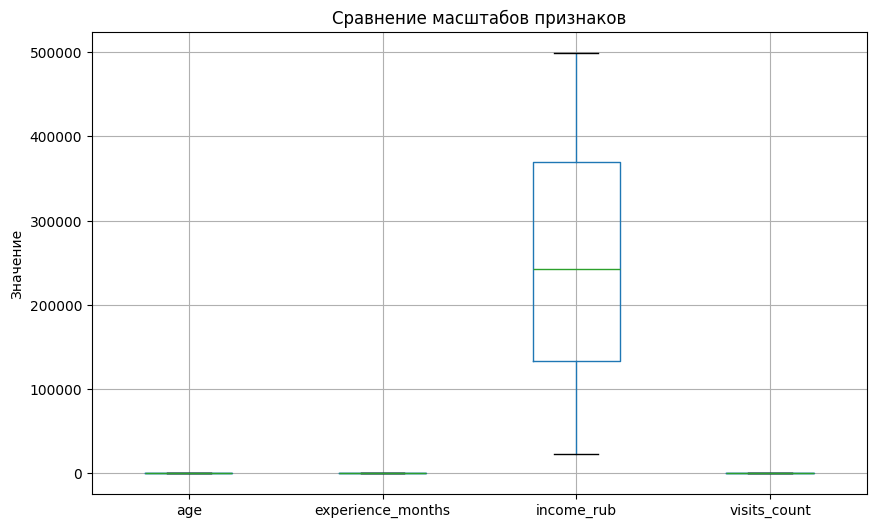

In [2]:
import matplotlib.pyplot as plt

# Устанавливаем размер фигуры (ширина 10, высота 6)
plt.figure(figsize=(10, 6))

# Строим boxplot (диаграмму размаха) для всех указанных признаков
df.boxplot(column=['age', 'experience_months', 'income_rub', 'visits_count'])

# Заголовок графика
plt.title('Сравнение масштабов признаков')

# Подпись оси Y
plt.ylabel('Значение')

# Показываем график
plt.show()

Признак `income_rub` сильно выделяется: его значения распределены гораздо шире (длинная коробка и усы) и находятся на значительно более высоком уровне (медиана выше).

Это значит, что у дохода иной масштаб и большой разброс, поэтому без предварительного масштабирования он будет доминировать над остальными признаками в модели.

#### Разбиение данных на выборки

Чтобы протестироваить маштабирование - не будем выделять валидационную выборку для простоты

In [3]:
from sklearn.model_selection import train_test_split

# Разделяем данные: 80% — для обучения, 20% — для тестирования
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Выводим размеры выборок
print(f"Размер обучающей выборки: {train_df.shape}")
print(f"Размер тестовой выборки: {test_df.shape}")

Размер обучающей выборки: (800, 4)
Размер тестовой выборки: (200, 4)


После разделения данных на обучающую и тестовую выборки можно проверить, что распределение ключевых признаков в них примерно одинаковое. Для этого посмотрим на распределение признака возраст ( age ) в обеих выборках.

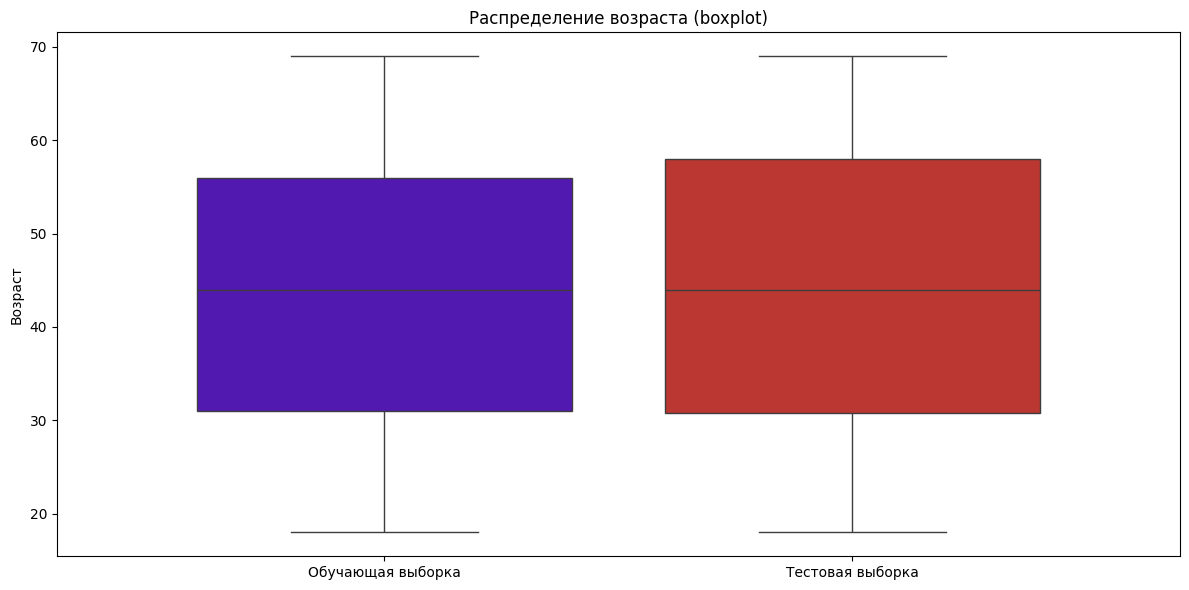

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Устанавливаем размер
plt.figure(figsize=(12, 6))

# Добавляем .values, чтобы Seaborn не группировал данные по одинаковому имени 'age'
sns.boxplot(data=[train_df['age'].values, test_df['age'].values], palette=['#4b00ca', '#d1241a'])

# Устанавливаем границы и подписи
plt.xlim(-0.7, 1.7)
plt.xticks([0, 1], ['Обучающая выборка', 'Тестовая выборка'])
plt.title('Распределение возраста (boxplot)')
plt.ylabel('Возраст')

plt.tight_layout()
plt.show()


Видно что распределение и порядок данных в обоих выборках одинаковый.

## Реализация масштабирования


Важное правило — все статистики считаем только по обучающей выборке.